In [45]:
import pandas as pd
from xgboost import XGBRFRegressor, XGBRegressor
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from datetime import datetime
from sklearn.linear_model import LinearRegression

In [46]:
DATA_PREFIX = "../data"
OUTPUT_PREFIX = "../output"

TRAIN_PARQUET = f"{OUTPUT_PREFIX}/train.parquet"
TEST_CSV = f"{DATA_PREFIX}/test.csv"
SUBMISSION_CSV = f"{DATA_PREFIX}/sample_submission.csv"

In [47]:
PREDICTORS = [
    # "row_id",
    # "x",
    # "y",
    "b02_s2.cdse.quarterly_xxxx0401_xxxx0631",
    "b04_s2.cdse.quarterly_xxxx0401_xxxx0631",
    "b08_s2.cdse.quarterly_xxxx0401_xxxx0631",
    "obs_s2.cdse.quarterly_xxxx0401_xxxx0631",
    "HH_dB_palsar_xxxx",
    "HV_dB_palsar_xxxx",
    "angle_palsar_xxxx",
    # "qa_palsar_xxxx",
    "vv.sentinel1_xxxx07",
    "vh.sentinel1_xxxx07",
    "bioregion",
    "forest_type",
    # "year",
    # "tile_id",
]

LABEL = "biomass"

In [48]:
train_df = pd.read_parquet(TRAIN_PARQUET)
train_df[[LABEL, *PREDICTORS]] = train_df[[LABEL, *PREDICTORS]].apply(pd.to_numeric, errors="coerce")
train_df = train_df[(train_df["b02_s2.cdse.quarterly_xxxx0401_xxxx0631"] > 0) & (train_df[LABEL] >= 0)].dropna()
train_df

,field_1,x,y,b02_s2.cdse.quarterly_xxxx0401_xxxx0631,b04_s2.cdse.quarterly_xxxx0401_xxxx0631,b08_s2.cdse.quarterly_xxxx0401_xxxx0631,obs_s2.cdse.quarterly_xxxx0401_xxxx0631,HH_dB_palsar_xxxx,HV_dB_palsar_xxxx,angle_palsar_xxxx,qa_palsar_xxxx,vv.sentinel1_xxxx07,vh.sentinel1_xxxx07,biomass,bioregion,forest_type,year,tile_id,geometry,geometry_bbox
0,1,3137124.7416963745,1810803.9191588927,306.0,422.0,2632.0,10.0,-7.452171,-12.639405,51.086891,255.0,1097.0,502.0,28.742064,9.0,9.0,2020,038052,b'\x01\x01\x00\x00\x00$\xe8\xef^2\xefGAH\xffM\...,"{'xmin': 3137124.25, 'ymin': 1810803.875, 'xma..."
1,3,3138084.7416963745,1808543.9191588927,292.0,380.0,3400.0,8.0,-7.566631,-12.543831,47.825680,255.0,2066.0,579.0,61.379017,9.0,9.0,2020,038052,b'\x01\x01\x00\x00\x00$\xe8\xef^\x12\xf1GAH\xf...,"{'xmin': 3138084.25, 'ymin': 1808543.875, 'xma..."
2,4,3136834.7416963745,1809903.9191588927,453.0,606.0,2684.0,11.0,-7.491881,-11.670959,43.808136,255.0,2264.0,418.0,41.445705,9.0,9.0,2020,038052,b'\x01\x01\x00\x00\x00$\xe8\xef^\xa1\xeeGAH\xf...,"{'xmin': 3136834.25, 'ymin': 1809903.875, 'xma..."
3,8,3137594.7416963745,1810823.9191588927,570.0,795.0,2452.0,9.0,-7.995021,-14.869256,26.739832,255.0,1638.0,407.0,25.911734,9.0,9.0,2020,038052,b'\x01\x01\x00\x00\x00$\xe8\xef^\x1d\xf0GAH\xf...,"{'xmin': 3137594.25, 'ymin': 1810823.875, 'xma..."
4,11,3137914.7416963745,1808923.9191588927,287.0,348.0,2386.0,9.0,-8.331754,-11.818994,29.713644,255.0,1219.0,351.0,40.892021,9.0,10.0,2020,038052,b'\x01\x01\x00\x00\x00$\xe8\xef^\xbd\xf0GAH\xf...,"{'xmin': 3137914.25, 'ymin': 1808923.875, 'xma..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5165029,16019521,3111664.7416963745,2243933.9191588927,304.0,429.0,3516.0,9.0,-8.826680,-16.066385,35.457657,255.0,1317.0,355.0,58.634174,9.0,0.0,2019,035805,b'\x01\x01\x00\x00\x00$\xe8\xef^x\xbdGA\xa4\xf...,"{'xmin': 3111664.25, 'ymin': 2243933.75, 'xmax..."
5165030,16019590,3111624.7416963745,2243883.9191588927,292.0,402.0,2464.0,9.0,-9.131854,-17.478987,35.740417,255.0,1623.0,334.0,60.487827,9.0,0.0,2019,035805,b'\x01\x01\x00\x00\x00$\xe8\xef^d\xbdGA\xa4\xf...,"{'xmin': 3111624.25, 'ymin': 2243883.75, 'xmax..."
5165031,16019669,3113104.7416963745,2243803.9191588927,354.0,524.0,2906.0,9.0,-9.694338,-18.159117,38.063908,255.0,1227.0,451.0,118.166924,9.0,8.0,2019,035805,b'\x01\x01\x00\x00\x00$\xe8\xef^H\xc0GA\xa4\xf...,"{'xmin': 3113104.25, 'ymin': 2243803.75, 'xmax..."
5165032,16019824,3113074.7416963745,2243833.9191588927,206.0,277.0,2818.0,10.0,-9.098869,-16.687696,38.181702,255.0,1322.0,411.0,104.021767,9.0,8.0,2019,035805,b'\x01\x01\x00\x00\x00$\xe8\xef^9\xc0GA\xa4\xf...,"{'xmin': 3113074.25, 'ymin': 2243833.75, 'xmax..."


In [49]:
# generate NDVI
NEW_PREDICTORS = PREDICTORS + ["NDWI", "NDVI", "RVI_PALSAR", "RVI_S1"]

train_df["NDVI"] = (
    train_df["b08_s2.cdse.quarterly_xxxx0401_xxxx0631"]
    - train_df["b04_s2.cdse.quarterly_xxxx0401_xxxx0631"]
) * (
    train_df["b08_s2.cdse.quarterly_xxxx0401_xxxx0631"]
    + train_df["b04_s2.cdse.quarterly_xxxx0401_xxxx0631"]
) * 1e4

train_df["NDWI"] = (
    (
        train_df["b02_s2.cdse.quarterly_xxxx0401_xxxx0631"]
        - train_df["b08_s2.cdse.quarterly_xxxx0401_xxxx0631"]
    )
    * (
        train_df["b02_s2.cdse.quarterly_xxxx0401_xxxx0631"]
        + train_df["b08_s2.cdse.quarterly_xxxx0401_xxxx0631"]
    )
    * 1e4
)

train_df["RVI_PALSAR"] = (
    (train_df["HH_dB_palsar_xxxx"] - train_df["HV_dB_palsar_xxxx"])
    * (train_df["HH_dB_palsar_xxxx"] + train_df["HV_dB_palsar_xxxx"])
    * 1e4
)

train_df["RVI_S1"] = (
    (train_df["vv.sentinel1_xxxx07"] - train_df["vh.sentinel1_xxxx07"])
    * (train_df["vv.sentinel1_xxxx07"] + train_df["vh.sentinel1_xxxx07"])
    * 1e4
)

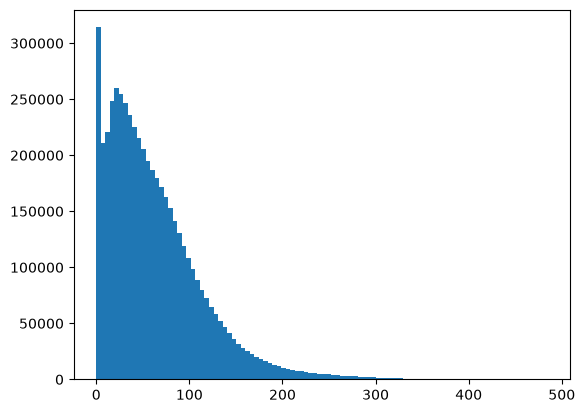

In [50]:
plt.hist(train_df[LABEL], bins=100)
plt.show()

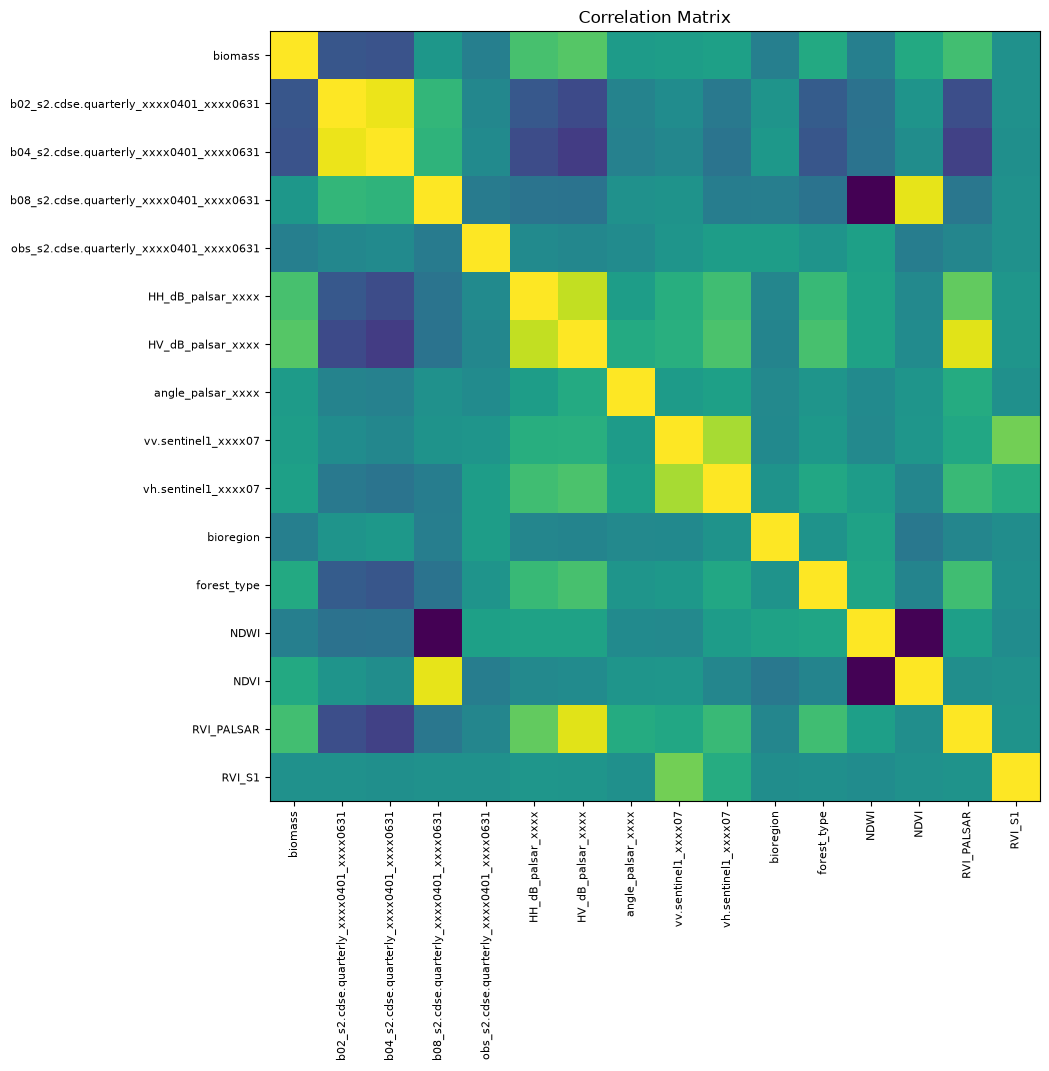

In [51]:
# generate correlation matrix
correlation = train_df[[LABEL, *NEW_PREDICTORS]].corr()

plt.figure(figsize=(10, 10))
plt.imshow(correlation)
plt.title("Correlation Matrix")
plt.xticks(
    range(len([LABEL, *NEW_PREDICTORS])), [LABEL, *NEW_PREDICTORS], size=8, rotation=90
)
plt.yticks(range(len([LABEL, *NEW_PREDICTORS])), [LABEL, *NEW_PREDICTORS], size=8)
plt.show()

In [52]:
# split train and test data
train, test = train_test_split(train_df, test_size=0.3)

In [53]:
MODEL_NAME = f"XGB_v1_{datetime.now().timestamp()}"
model = XGBRegressor(n_estimators=500)
model.fit(train[NEW_PREDICTORS], train[LABEL])

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [54]:
total = sum(model.feature_importances_)
print("Feature importance")
pd.Series(dict(zip(model.feature_names_in_, model.feature_importances_ / total * 100)))

Feature importance


b02_s2.cdse.quarterly_xxxx0401_xxxx0631     3.663586
b04_s2.cdse.quarterly_xxxx0401_xxxx0631    37.829437
b08_s2.cdse.quarterly_xxxx0401_xxxx0631     1.492892
obs_s2.cdse.quarterly_xxxx0401_xxxx0631     5.224699
HH_dB_palsar_xxxx                           3.968131
HV_dB_palsar_xxxx                          15.444223
angle_palsar_xxxx                           1.651949
vv.sentinel1_xxxx07                         1.352684
vh.sentinel1_xxxx07                         1.704174
bioregion                                   6.401896
forest_type                                 5.309222
NDWI                                        1.857080
NDVI                                        8.064402
RVI_PALSAR                                  0.582889
RVI_S1                                      5.452734
dtype: float32

In [55]:
test_apply = model.predict(test[NEW_PREDICTORS])
r2 = np.corrcoef(test[LABEL], test_apply)[0, 1] ** 2
mae = mean_absolute_error(test[LABEL], test_apply)
print(f"R^2={r2}", f"MAE={mae}")

R^2=0.652154445330762 MAE=20.97452895611816


In [56]:
test_df = pd.read_csv(TEST_CSV)
test_df

,Unnamed: 0,row_id,x,y,b02_s2.cdse.quarterly_xxxx0401_xxxx0631,b04_s2.cdse.quarterly_xxxx0401_xxxx0631,b08_s2.cdse.quarterly_xxxx0401_xxxx0631,obs_s2.cdse.quarterly_xxxx0401_xxxx0631,HH_dB_palsar_xxxx,HV_dB_palsar_xxxx,angle_palsar_xxxx,qa_palsar_xxxx,vv.sentinel1_xxxx07,vh.sentinel1_xxxx07,bioregion,forest_type,year,tile_id
0,24,028631_3040064_2251003,3.040065e+06,2.251004e+06,100.0,103.0,2788.0,21.0,-10.144670,-13.913869,62.935490,255.0,4345.0,1192.0,9.0,9.0,2021,28631
1,30,028631_3041214_2252063,3.041215e+06,2.252064e+06,171.0,208.0,2746.0,20.0,-7.349724,-10.590984,42.061958,255.0,1360.0,335.0,9.0,9.0,2021,28631
2,33,028631_3041184_2251693,3.041185e+06,2.251694e+06,98.0,91.0,3664.0,21.0,-6.874915,-12.238380,41.123703,255.0,2078.0,615.0,9.0,9.0,2021,28631
3,38,028631_3039864_2250783,3.039865e+06,2.250784e+06,98.0,131.0,3060.0,20.0,-5.991528,-10.575653,52.339672,255.0,2116.0,548.0,9.0,9.0,2021,28631
4,64,028631_3040224_2251483,3.040225e+06,2.251484e+06,72.0,88.0,3772.0,22.0,-6.046557,-10.341457,48.277470,255.0,2367.0,385.0,9.0,9.0,2021,28631
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45014,884113,061751_3374644_2043173,3.374645e+06,2.043174e+06,287.0,323.0,4392.0,17.0,-9.803984,-15.310058,37.016045,255.0,1363.0,397.0,9.0,9.0,2020,61751
45015,885387,061751_3374594_2043203,3.374595e+06,2.043204e+06,608.0,922.0,3732.0,17.0,-11.813272,-15.730301,38.029926,255.0,1387.0,277.0,9.0,0.0,2020,61751
45016,890670,061751_3374624_2043173,3.374625e+06,2.043174e+06,212.0,268.0,3086.0,17.0,-11.729067,-16.882254,36.219688,255.0,1336.0,308.0,9.0,9.0,2020,61751
45017,895641,061751_3374614_2043223,3.374615e+06,2.043224e+06,153.0,215.0,3280.0,17.0,-7.831328,-13.507510,35.155594,255.0,2629.0,603.0,9.0,0.0,2020,61751


In [57]:
test_df["NDVI"] = (
    (
        train_df["b08_s2.cdse.quarterly_xxxx0401_xxxx0631"]
        - train_df["b04_s2.cdse.quarterly_xxxx0401_xxxx0631"]
    )
    * (
        train_df["b08_s2.cdse.quarterly_xxxx0401_xxxx0631"]
        + train_df["b04_s2.cdse.quarterly_xxxx0401_xxxx0631"]
    )
    * 1e4
)

test_df["NDWI"] = (
    (
        train_df["b02_s2.cdse.quarterly_xxxx0401_xxxx0631"]
        - train_df["b08_s2.cdse.quarterly_xxxx0401_xxxx0631"]
    )
    * (
        train_df["b02_s2.cdse.quarterly_xxxx0401_xxxx0631"]
        + train_df["b08_s2.cdse.quarterly_xxxx0401_xxxx0631"]
    )
    * 1e4
)

test_df["RVI_PALSAR"] = (
    (train_df["HH_dB_palsar_xxxx"] - train_df["HV_dB_palsar_xxxx"])
    * (train_df["HH_dB_palsar_xxxx"] + train_df["HV_dB_palsar_xxxx"])
    * 1e4
)

test_df["RVI_S1"] = (
    (train_df["vv.sentinel1_xxxx07"] - train_df["vh.sentinel1_xxxx07"])
    * (train_df["vv.sentinel1_xxxx07"] + train_df["vh.sentinel1_xxxx07"])
    * 1e4
)

test_df

,Unnamed: 0,row_id,x,y,b02_s2.cdse.quarterly_xxxx0401_xxxx0631,b04_s2.cdse.quarterly_xxxx0401_xxxx0631,b08_s2.cdse.quarterly_xxxx0401_xxxx0631,obs_s2.cdse.quarterly_xxxx0401_xxxx0631,HH_dB_palsar_xxxx,HV_dB_palsar_xxxx,...,vv.sentinel1_xxxx07,vh.sentinel1_xxxx07,bioregion,forest_type,year,tile_id,NDVI,NDWI,RVI_PALSAR,RVI_S1
0,24,028631_3040064_2251003,3.040065e+06,2.251004e+06,100.0,103.0,2788.0,21.0,-10.144670,-13.913869,...,4345.0,1192.0,9.0,9.0,2021,28631,6.749340e+10,-6.833788e+10,-1.042197e+06,9.514050e+09
1,30,028631_3041214_2252063,3.041215e+06,2.252064e+06,171.0,208.0,2746.0,20.0,-7.349724,-10.590984,...,1360.0,335.0,9.0,9.0,2021,28631,1.141560e+11,-1.147474e+11,-1.000938e+06,3.933115e+10
2,33,028631_3041184_2251693,3.041185e+06,2.251694e+06,98.0,91.0,3664.0,21.0,-6.874915,-12.238380,...,2078.0,615.0,9.0,9.0,2021,28631,6.836620e+10,-6.998647e+10,-8.008299e+05,4.950972e+10
3,38,028631_3039864_2250783,3.039865e+06,2.250784e+06,98.0,131.0,3060.0,20.0,-5.991528,-10.575653,...,2116.0,548.0,9.0,9.0,2021,28631,5.380279e+10,-5.687404e+10,-1.571744e+06,2.517395e+10
4,64,028631_3040224_2251483,3.040225e+06,2.251484e+06,72.0,88.0,3772.0,22.0,-6.046557,-10.341457,...,2367.0,385.0,9.0,9.0,2021,28631,5.571892e+10,-5.610627e+10,-7.027049e+05,1.362760e+10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45014,884113,061751_3374644_2043173,3.374645e+06,2.043174e+06,287.0,323.0,4392.0,17.0,-9.803984,-15.310058,...,1363.0,397.0,9.0,9.0,2020,61751,4.068372e+10,-4.271872e+10,-1.019509e+06,1.273941e+10
45015,885387,061751_3374594_2043203,3.374595e+06,2.043204e+06,608.0,922.0,3732.0,17.0,-11.813272,-15.730301,...,1387.0,277.0,9.0,0.0,2020,61751,7.807536e+10,-7.963200e+10,-1.327227e+06,1.127807e+10
45016,890670,061751_3374624_2043173,3.374625e+06,2.043174e+06,212.0,268.0,3086.0,17.0,-11.729067,-16.882254,...,1336.0,308.0,9.0,9.0,2020,61751,9.326592e+10,-9.884476e+10,-2.279756e+06,9.715350e+09
45017,895641,061751_3374614_2043223,3.374615e+06,2.043224e+06,153.0,215.0,3280.0,17.0,-7.831328,-13.507510,...,2629.0,603.0,9.0,0.0,2020,61751,5.773437e+10,-6.062336e+10,-1.029284e+06,6.937600e+09


In [58]:
submission_df = pd.read_csv(SUBMISSION_CSV)
submission_df

,Id,Expected
0,028631_3040064_2251003,0.0
1,028631_3041214_2252063,0.0
2,028631_3041184_2251693,0.0
3,028631_3039864_2250783,0.0
4,028631_3040224_2251483,0.0
...,...,...
45014,061751_3374644_2043173,0.0
45015,061751_3374594_2043203,0.0
45016,061751_3374624_2043173,0.0
45017,061751_3374614_2043223,0.0


In [59]:
submission_df["Expected"] = model.predict(test_df[NEW_PREDICTORS])
submission_df

,Id,Expected
0,028631_3040064_2251003,236.791183
1,028631_3041214_2252063,222.602264
2,028631_3041184_2251693,271.746857
3,028631_3039864_2250783,234.496643
4,028631_3040224_2251483,281.975220
...,...,...
45014,061751_3374644_2043173,67.199539
45015,061751_3374594_2043203,33.264832
45016,061751_3374624_2043173,74.802719
45017,061751_3374614_2043223,88.207359


In [60]:
RESULT_CSV = f"{OUTPUT_PREFIX}/results_{MODEL_NAME}.csv"
submission_df.to_csv(RESULT_CSV, index=False)

MODEL_NAME

'XGB_v1_1787122805.130853'